In [2]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")


In [ ]:
# To ignore all warnings
import warnings
warnings.filterwarnings("ignore")


In [155]:
download_libraries("check")

Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
ERROR: Could not find a version that satisfies the requirement matplotlib.pyplot (from versions: none)
ERROR: No matching distribution found for matplotlib.pyplot
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to use updated packages.
Note: you may need to restart the kernel to u

In [57]:
def download_libraries(command):
    if command=="check":
        %pip install numpy
        %pip install pandas
        %pip install seaborn
        %pip install matplotlib.pyplot
        %pip install matplotlib
        %pip install pandas_datareader
        %pip install scikit-learn
        %pip install getFamaFrenchFactors
        %pip install matplotlib 
        %pip install pandas-datareader 
        %pip install scikit-learn 
        %pip install plotly 
        %pip install ipython 
        %pip install random 
        %pip install yfinance 
        %pip install statsmodels 
        %pip install pulp
        %pip install pyarrow
        %pip install setuptools
        %pip install --upgrade certifi
        %pip install openpyxl



In [3]:
import matplotlib.pyplot as plt
import numpy as np, numpy.random
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import datetime as dt
import calendar
from sklearn.linear_model import LinearRegression
import plotly.express as px
from IPython.display import Markdown as md
import random as rand
from matplotlib import gridspec
import yfinance as yf
from datetime import datetime
import getFamaFrenchFactors as gff
from pandas.tseries.offsets import DateOffset
from statsmodels.formula.api import ols
import statsmodels.api as sm
import random
yf.pdr_override()
import pulp
from sklearn.preprocessing import LabelEncoder
import pandas_datareader.data as reader
import yfinance as yf
import pandas as pd
import requests
import getFamaFrenchFactors as gff
from pulp import LpProblem, LpMaximize, LpVariable, LpMinimize, LpBinary, lpSum
from pulp import *

In [4]:
def get_spy(beta1,beta2,beta3,start,end):
  
    global tickers
    requests.packages.urllib3.disable_warnings() 
    # Fetch HTML content
    response = requests.get('https://en.wikipedia.org/wiki/List_of_S%26P_500_companies', verify=False)
    html_content = response.content
    # Read HTML content into pandas DataFrame
    list_of_dfs = pd.read_html(html_content)
    wikitable_sp_500 = list_of_dfs[0]
    sp500_symbols = wikitable_sp_500['Symbol']#Converting SP_500 tickers into list 
    tickers = sp500_symbols.to_list()#Remove some tickers as they create an error for the yfinance api
    tickers[65] = 'BRK-B'
    tickers[81] = 'BF-B'
    tickers.remove('BF-B')
    tickers.remove('BRK-B')#Start Date for In Sample Historical Data
    global monthly_data
    global base_w
    monthly_data = yf.download(tickers,start=start,end=end,interval='1mo')#Reformat Date Index 
    monthly_data.index = pd.to_datetime(monthly_data.index)
    monthly_data = monthly_data.tz_localize(None)#Turn Adj Close prices into pct returns
    monthly_data = monthly_data['Adj Close'].pct_change()#Drop First row NaN values
    monthly_data = monthly_data.drop(monthly_data.index[0])#Drop if stock doesnt have data starting from the first index date
    monthly_data = monthly_data.dropna(axis=1)#Assign equal weight as base weights
    
    base_w = {k: 1/len(monthly_data.columns) for k in monthly_data.columns}
    base_w = pd.DataFrame.from_dict(base_w, orient='index', columns=['Weight'])#Getting SP_500 data
    spy = pd.DataFrame(yf.download('^GSPC',start=start,end=end,interval='1mo')['Adj Close'].pct_change())#Dropping First Row(NaN) and formatting index to match monthly_data 
    spy = spy.drop(spy.index[0]).tz_localize(None)#Adding SP_500 data to monthly_data
    monthly_data['SP_500'] = spy['Adj Close']
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']

    

In [5]:
def famafrenchreturns():
    global ff3_monthly
    # Fama French Monthly Returns Data using getFamaFrenchFactors module
    ff3_monthly = gff.famaFrench3Factor(frequency='m')
    ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
    ff3_monthly.set_index('Date', inplace=True)
    ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
    # Keeping Only the Dates in the monthly_data
    ff3_monthly = ff3_monthly.loc[monthly_data.index]
    

In [6]:
def to__cal_stock_betas():
    global stock_betas
    stock_betas = pd.DataFrame()
    # Iterate over the tickers list
    for col in monthly_data.columns:
        # Set the dependent variable (Return of stock i)
        y = monthly_data[col]
        # Set the independent variables (Fama French 3 Factors)
        X = ff3_monthly[['Mkt-RF','SMB','HML']]
        # Fit the multiple linear regression model
        model = LinearRegression()
        model.fit(X, y)
        # Store the results in the DataFrame
        stock_betas[col] = [model.intercept_] + list(model.coef_)
    stock_betas = stock_betas.T
    stock_betas.columns = ['Intercept','Mkt-RF','SMB','HML']

In [7]:
def to_cal_stock_price():
    global stock_price
    global s_price
    global s_keys
    global s_values
    #Stock Prices on the Day of Optimization(Rebalancing)
    stock_price = pd.DataFrame(yf.download(tickers,start=start,end=end,interval='1d')['Adj Close'])
    stock_price = stock_price[-1:]
    stock_price.index = pd.to_datetime(stock_price.index).tz_localize(None)
    s_price = {}
    s_keys = list(tickers)
    s_values =  list(stock_price.iloc[0])
    for key,value in zip(s_keys,s_values):
        s_price[key] = value

In [8]:
def Transaction_Costs():
    #Transaction_Costs
    random.seed(1)
    global t_cost
    t_cost = {}
    global keys
    keys = list(tickers)
    #values     = [.15 for i in range(len(keys))] 
    values = list(random.uniform(.01,.02) for i in range(len(tickers)))
    for key,value in zip(keys,values):
        t_cost[key] = value

In [9]:
def optimization():
# OPTIMIZATION MODEL
    global index
    global wei
    global aux
    global err
    global binary
    global tr_cost
    global shares
    index = LpProblem('Index', LpMinimize) 
    # Decision Variables
    wei = LpVariable.dicts('Weight',tickers,lowBound=0)                           # Weights for stock i in the optimal portfolio
    aux = LpVariable.dicts('Y',tickers,lowBound=0)                                # Absolute value of change for stock i from base weights
    err = LpVariable.dicts('Error', monthly_data.index, lowBound=0)               # Error term for portfolio
    binary = LpVariable.dicts('bin',tickers,cat=LpBinary)                         # Used if we want to limit the # of stocks we want to have in optimal portfolio
    tr_cost = LpVariable.dicts('Transaction_Cost',tickers,lowBound=0)             # Total Transaction cost for stock i in the optimal portfolio
    shares = LpVariable.dicts('shares',tickers,lowBound=0)                        # Total Transaction cost for stock i in the optimal portfolio
    #Objective Function - Minimize the error term 
    index +=  lpSum(err[t] for t in monthly_data.index) # Constraint: Weights sum to 1 
    index += lpSum(wei[i] for i in tickers) == 1
    # Constraint: Absolute value of change in weights from base weigths
    for i in tickers:
        index += aux[i] >= base_weights[i]  - wei[i]
        index += aux[i] >= wei[i] - base_weights[i]
    index += lpSum(aux[i] for i in tickers) <= 1 
    # Constraint: Error term
    for t in monthly_data.index:
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) - err[t] <= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
        index += lpSum(wei[i]*(monthly_data.loc[t,i]-ff3_monthly.loc[t,'RF']) for i in tickers) + err[t] >= (mkt_opt*ff3_monthly.loc[t,'Mkt-RF']+smb_opt*ff3_monthly.loc[t,'SMB']+hml_opt*ff3_monthly.loc[t,'HML'])
    # Shares
    for i in tickers:
        index += shares[i] == (aux[i]*B/s_price[i])
    # Transaction Costs
    for i in tickers:
        index += lpSum(aux[i] *B*t_cost[i]/s_price[i]) == tr_cost[i]
    index += lpSum(tr_cost[i] for i in tickers) <= 2000
    # Limit # of stocks in Optimal Portfolio
    for i in tickers: # Forces weight of stock i to be less than binary value of stock i. If stock is not selected binary variable is 0 which then forces weight of stock i to be in the optimal portfolio to be 0.
        index += wei[i] <= binary[i]
    index += lpSum(binary[i] for i in tickers) <= q
    index.solve()
    

In [10]:
def others():
    global sharess
    #Change in number of shares
    sharess = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 's'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 's'] , columns = ['Optimal'])
    sharess
    global tr_cost
    #Transaction Costs
    tr_cost = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'T'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'T'] , columns = ['Optimal'])
    tr_cost.sum()
    global weii
    #Optimal weights
    weii = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'W'] , columns = ['Optimal'])
    weii.sum()
    global auxx
    #Change of weights
    auxx = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'Y'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'Y'] , columns = ['Optimal'])
    auxx.sum()
    global errr
    #Error terms
    errr = pd.DataFrame([v.varValue for v in index.variables() if str(v.name)[0] == 'E'], index = [str(v.name) for v in index.variables() if str(v.name)[0] == 'E'] , columns = ['Optimal'])
    errr.sum()
    global binary_v
    # Check if Binary Values Constraint works
    binary_v = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'b'] , columns = ['Optimal'])
    binary_v.sum()
    global opt_weights 
    # Weights in Optimal Portfolio
    opt_weights = pd.DataFrame([v.varValue for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'], index = [str(v.name) for v in index.variables() if v.varValue != 0 and str(v.name)[0] == 'W'] , columns = ['Optimal'])
    opt_weights.style.format('{:,.2%}'.format)
    global weights_new
    weights_new = pd.DataFrame([v.varValue for v in index.variables() if str(v.name[0]) == 'W'], index = [str(v.name).split('_')[1] for v in index.variables() if str(v.name[0]) == 'W'] , columns = ['New Weights'])
    global weights
    weights = pd.DataFrame(np.zeros((len(monthly_data.columns[:-1]),3)), index=monthly_data.columns[:-1], columns=['PORTFOLIO Weights','Difference','New Weights'])
    for t in monthly_data.columns[:-1]:
        weights.loc[t][0] = base_w.loc[t]
        weights.loc[t][1] = weights_new.loc[t][0]-base_w.loc[t][0]
        weights.loc[t][2] = weights_new.loc[t]
    weights
    columns_to_remove = ['PORTFOLIO Weights', 'Difference']
    # Specify the column to filter non-zero values
    column_to_filter = 'New Weights'
    # Create a new DataFrame with selected columns and rows where New Weights is not equal to 0
    global opt_portf_weights
    opt_portf_weights = weights.drop(columns=columns_to_remove)[weights[column_to_filter] != 0]




In [11]:
def portfolio_betas():
    # CHECK PORTFOLIO BETAS
   
    global port_betas
    port_returns = pd.DataFrame(np.zeros((len(monthly_data.index),2)), index=monthly_data.index, columns=["SP_500","Optimization"])
    for j in port_returns.index:
        port_returns.loc[j]["SP_500"] = monthly_data.loc[j]['SP_500']
        port_returns.loc[j]['Optimization'] = monthly_data.loc[j,:monthly_data.columns[-2]].dot(weights['New Weights'])
    port_returns = port_returns.merge(ff3_monthly[['Mkt-RF','SMB','HML']], left_index=True, right_index=True)
    # Create an empty DataFrame to store the Portfolio Beta
    port_betas = pd.DataFrame(np.zeros((3,4)), index=ff3_monthly.columns[0:3], columns=["SP_500", "Target", "Optimization", "Abs. Diff"])
    port_betas["Target"] = [mkt_opt, smb_opt, hml_opt]# Set the independent variables (Fama French 3 Factors)
    X = port_returns[['Mkt-RF','SMB','HML']]
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['SP_500']# Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['SP_500'] = regr.coef_
    # Set the dependent variable (Return of Portfolio)
    Y = port_returns['Optimization']
    # Fit the multiple linear regression model
    regr = LinearRegression()
    regr.fit(X,Y)
    port_betas['Optimization'] = regr.coef_
    # Abs Difference between Target Betas & Optimal Portfolio Betas
    port_betas["Abs. Diff"] = round(abs(port_betas['Optimization'] - port_betas["Target"]),4)
    port_betas
    return port_betas
    

In [12]:
def simulator(beta1,beta2,beta3,begin,final,budget,number):
    global start
    global end
    start=begin
    end=final
    get_spy(beta1,beta2,beta3,start,end)
    #Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
    global tickers
    tickers = list(monthly_data.columns[:-1])
    tick_index = tickers + ['SP_500']
    

    # TARGET FACTOR BETAS 
    global base_weights
    global mkt_opt
    global smb_opt
    global hml_opt
    global B
    global q
    
    mkt_opt = beta1                          # TARGET MKT BETA - EXPOSURE OF THE NEW PORTFOLIO TO MARKET FACTOR 
    smb_opt = beta2                           # TARGET SMB BETA - EXPOSURE OF THE NEW PORTFOLIO TO SIZE FACTOR 
    hml_opt = beta3                           # TARGET HML BETA - EXPOSURE OF THE NEW PORTFOLIO TO VALUE FACTOR 
    B = budget                             # BUDGET
    q = number                                # NUMBER OF STOCKS IN THE NEW PORTFOLIO
    base_weights = base_w.T*0               # ONLY HAVE THIS LINE OF CODE WHEN YOU ARE CONSTRUCTING THE PORTFOLIO FROM SCRATCH 
    
    famafrenchreturns()
    to__cal_stock_betas()
    to_cal_stock_price()
    Transaction_Costs()
    optimization()
    others()
    portfolio_betas()
    opt_portf_weights
    global port_betas
    opt_portf_weights


In [240]:
def out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    global o1_end_d
    global o1_start_d
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = yf.download(opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d,interval='1mo')
    oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [292]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    last_key = list(out_of_sample_year_end.keys())[-1]
    o1_end_d   = out_of_sample_year_end[last_key]
    oos1_daily_data = yf.download(opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d,interval='1mo')
    oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [ ]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = yf.download(opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d,interval='1mo')
    oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [14]:
def run_with_backtest(nyears):
    
    global n_years
    n_years=nyears
    current_date()
    simulator(1,0,0,n_year_before,n_year_after,1000000,50) 
    out_of_sample()
  
    return oos1_new_performance
    
    


In [29]:
run_with_backtest(3)

[*********************100%%**********************]  501 of 501 completed

6 Failed downloads:
['GEV', 'SOLV', 'SW', 'VLTO']: Exception("%ticker%: Data doesn't exist for startDate = 1593576000, endDate = 1688184000")
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-07-01 -> 2023-07-01)')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  490 of 490 completed


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ec571974d6f548159b38bc2b8b6889e4-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ec571974d6f548159b38bc2b8b6889e4-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2529 COLUMNS
At line 44769 RHS
At line 47294 BOUNDS
At line 47785 ENDATA
Problem MODEL has 2524 rows, 2485 columns and 41224 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1054 rows, 1505 columns (490 integer (490 of which binary)) and 38284 elements
Cbc0038I Initial state - 36 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 2.18104 ite

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed


Ticker,SP_500,Optimized Portfolio
Date,,
2023-08-01,1.000000,1.000000
2023-09-01,0.982284,0.983371
2023-10-01,0.934427,0.939009
2023-11-01,0.913889,0.906084
2023-12-01,0.995389,0.993394
2024-01-01,1.039414,1.047563
2024-02-01,1.055936,1.053306
2024-03-01,1.110550,1.061896
2024-04-01,1.144998,1.088326


In [15]:
def current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    from datetime import datetime, timedelta
    today = datetime.today()
    one_year_before = today - timedelta(days=365)
    os_start = today - timedelta(days=365)
    two_months_before = os_start - timedelta(days=2*30)
    os_start = two_months_before.replace(day=1)
    one_month_before = today - timedelta(days=30)
    os_end = one_month_before.replace(day=1)
    
    n_year_before = os_start - timedelta(days=(365*n_years))
    n_year_after=n_year_before+timedelta(days=(365*n_years))                           
    os_start=os_start.strftime("%Y-%m-%d")
    os_end=os_end.strftime("%Y-%m-%d")
    n_year_before=n_year_before.strftime("%Y-%m-%d")
    n_year_after=n_year_after.strftime("%Y-%m-%d")
    from datetime import date

    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date


In [213]:
def mod_out_of_sample():
    global oos1_daily_data
    global oos1_new_performance
    o1_start_d = os_start
    o1_end_d   = os_end
    oos1_daily_data = yf.download(opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d,interval='1mo')
    oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [264]:
def mod_out_of_sample1():
    global oos1_daily_data
    global oos1_spy_d
    global oos1_new_performance
    global o1_start_d
    global o1_end_d
    o1_start_d = out_of_sample_year_start[1]
    o1_end_d   = out_of_sample_year_end[2]
    oos1_daily_data = yf.download(opt_portf_weights.index.tolist(),start=o1_start_d,end=o1_end_d,interval='1mo')
    oos1_daily_data = oos1_daily_data['Adj Close'].pct_change().dropna()
    oos1_daily_data = oos1_daily_data.tz_localize(None)
    oos1_spy_d = pd.DataFrame(yf.download('^GSPC',start=o1_start_d,end=o1_end_d,interval='1mo')['Adj Close'].pct_change())
    oos1_spy_d = oos1_spy_d.drop(oos1_spy_d.index[0]).tz_localize(None)
    oos1_daily_data['SP_500'] = oos1_spy_d['Adj Close']
    oos1_daily_data['Optimized Portfolio'] = ''
    for i in range(len(oos1_daily_data.index)):
        oos1_daily_data.iloc[i,-1] = oos1_daily_data.iloc[i,:-2].dot(opt_portf_weights['New Weights'])
    oos1_daily_data
    oos1_new_returns = pd.DataFrame(np.ones((len(oos1_daily_data),len(oos1_daily_data.columns))), index = oos1_daily_data.index, columns = oos1_daily_data.columns)
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_returns.iloc[j] = oos1_new_returns.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns])
    oos1_new_performance = pd.DataFrame(np.ones((len(oos1_daily_data),2)), index = oos1_daily_data.index, columns = oos1_daily_data.columns[-2:])
    for j in range(1,len(oos1_daily_data.index)):
        oos1_new_performance.iloc[j] = oos1_new_performance.iloc[j-1]*(oos1_daily_data.iloc[j-1][oos1_daily_data.columns[-2:]]+1)
    
    return oos1_new_performance

In [18]:
def new_date_calculation():
    from datetime import datetime, timedelta
    from datetime import date
    today = datetime.now()
    global out_of_sample_year_start
    global out_of_sample_year_end
    out_of_sample_year_start={}
    out_of_sample_year_end={}
    for year in range(os_years):
        out_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * (os_years - year)))
        two_months_before = out_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        out_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=out_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        out_of_sample_year_end[(year+1)]=out_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        out_of_sample_year_start[(year+1)]=out_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        out_of_sample_year_end[(year+1)]=out_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")                        
    
    global in_of_sample_year_start
    in_of_sample_year_start={}
    global in_of_sample_year_end
    in_of_sample_year_end={}
    for year in range(in_years):
        in_of_sample_year_start[(year+1)] = today - timedelta(days=(365 * ((in_years+os_years) - year)))
        two_months_before = in_of_sample_year_start[(year+1)] - timedelta(days=2 * 30)
        in_of_sample_year_start[(year+1)] = two_months_before.replace(day=1)
        years=in_of_sample_year_start[(year+1)].year
        if (years % 4 == 0 and years % 100 != 0) or (years % 400 == 0):
            is_leap_year = True
            no_days_in_year = 366
        else:
            is_leap_year = False
            no_days_in_year = 365
        in_of_sample_year_end[(year+1)]=in_of_sample_year_start[(year+1)]+ timedelta(days=no_days_in_year-1)
        in_of_sample_year_start[(year+1)]=in_of_sample_year_start[(year+1)].strftime("%Y-%m-%d")
        in_of_sample_year_end[(year+1)]=in_of_sample_year_end[(year+1)].strftime("%Y-%m-%d")
    today = date.today()
    formatted_date = today.strftime("%Y-%m-%d")
    today = formatted_date

    




In [513]:
def new_run_with_backtest(inyears,outyears):
    
    global os_years
    global in_years
    os_years=outyears
    in_years=inyears
    global performances
    performances={}
    global spy_performances
    spy_performances={}
    global new_performances
    new_performances={}
    global new_spy_performances
    new_spy_performances={}
    new_date_calculation()
    global n_year_before
    global n_year_after
    n_year_before=in_of_sample_year_start[1]
    n_year_after=in_of_sample_year_end[in_years]
    simulator(1,0,0,n_year_before,n_year_after,1000000,50)
    global checklist
    checklist=[]
    for k in range(os_years): 
        global os_start
        global os_end
        global oos1_new_performances
        oos1_new_performances={}
        global init
        os_start=out_of_sample_year_start[1+k]
        os_end=out_of_sample_year_end[1+k]
        out_of_sample()
        # mod_out_of_sample()
        
        checklist.append(oos1_new_performance)
        if k == 0:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1]
        else:
            performances[k + 1] = oos1_new_performance["Optimized Portfolio"].iloc[-1] * performances[k]
            spy_performances[k + 1] = oos1_new_performance["SP_500"].iloc[-1] * spy_performances[k]
    mod_out_of_sample1()
    for kk in range(os_years): 
        placeholder=oos1_new_performance.index[0]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
        # performances[k + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
        placeholder=placeholder.replace(year=placeholder.year+(kk+1))
        if placeholder in oos1_new_performance.index:
            new_spy_performances[kk + 1] = oos1_new_performance.loc[placeholder,"SP_500"]
            new_performances[kk + 1] = oos1_new_performance.loc[placeholder,"Optimized Portfolio"]
    
    new_spy_performances[os_years] = oos1_new_performance.iloc[-1].loc["SP_500"]
    new_performances[os_years] = oos1_new_performance.iloc[-1].loc["Optimized Portfolio"]
    
            
            
        

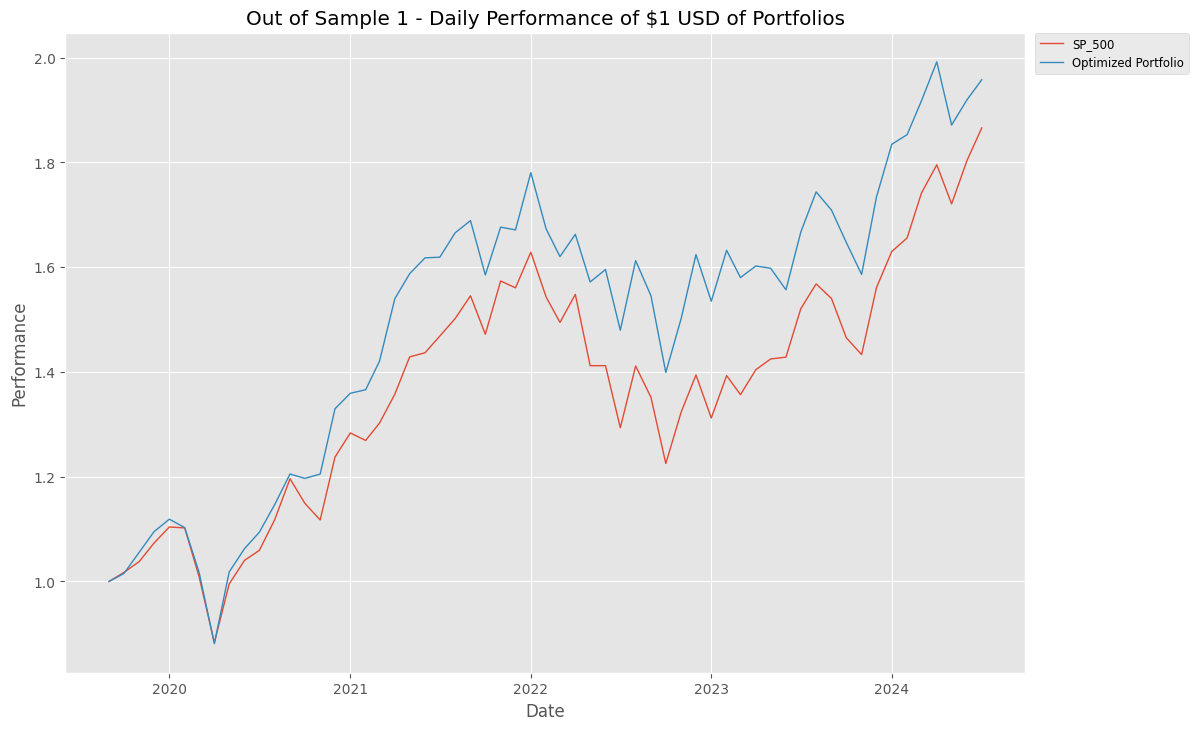

In [532]:
visual()

In [538]:
def monte_carlo_simulation(n_simulations):
    results = []
    yearly_returns=[]
    for i in range(n_simulations):
        new_run_with_backtest(3,5)
        globals()[f'x{i}_df']=oos1_new_performance.copy()
        globals()[f'y{i}_df']=new_performances.copy()
        results.append(globals()[f'x{i}_df'])
        yearly_returns.append(globals()[f'y{i}_df'])
        # results.append(oos1_new_performance.deepcopy())
        # results.append(oos1_new_performance.deepcopy())
        # yearly_returns.append(new_performances.__deepcopy__copy())
        # results[f'os_df{i}'] = oos1_new_performance.copy()
        # yearly_returns[f'return_df{i}'] = new_performances.copy()
        # results.append(oos1_new_performance)
        # yearly_returns.append(new_performances)
    
    sums = {key: 0 for key in yearly_returns[0]}
    for d in yearly_returns:
        for key, value in d.items():
            sums[key] += value
    num_dicts = len(yearly_returns)
    averages = {key: sums[key] / num_dicts for key in sums}
    return results,yearly_returns,averages

In [558]:
sums = {key: 0 for key in checkreturns[0]}
for d in checkreturns:
    for key, value in d.items():
        sums[key] += value
num_dicts = len(checkreturns)
averages = {key: sums[key] / num_dicts for key in sums}

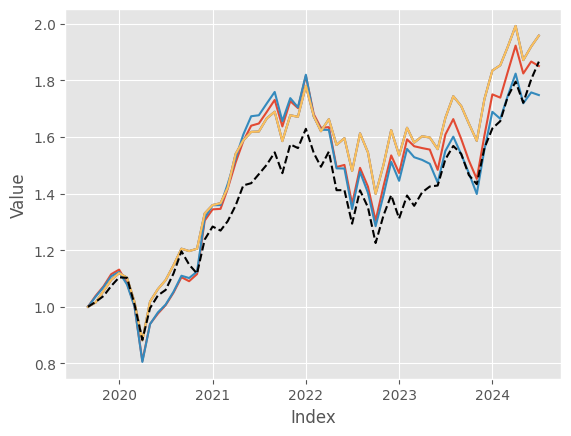

In [564]:

fig, ax = plt.subplots(figsize=(12, 8))
for i, df in enumerate(checkresults):
    ax.plot(df['Optimized Portfolio'], label=f' optimized_{i + 1}')
ax.plot(checkresults[-1]['SP_500'], label='SP_500', linestyle='--', color='black')
ax.set_xlabel('Index')
ax.set_ylabel('Value')
# ax.set_title('Feature Column from Each DataFrame with Extra Column from Last DF')
# ax.legend()
plt.show()


In [567]:
finaldf1 = pd.DataFrame(averages)
finaldf2 = pd.DataFrame(new_spy_performances)

ValueError: If using all scalar values, you must pass an index

In [556]:

checkresults=[x0_df,x1_df,x2_df,x3_df,x4_df]
checkreturns=[y0_df,y1_df,y2_df,y3_df,y4_df]

In [ ]:

checkresults=[x0_df,x1_df,x2_df,x3_df,x4_df]
checkreturns=[y0_df,y1_df,y2_df,y3_df,y4_df]

In [572]:
new_spy_performances

{}

1000 nodes, 39197 on tree, 0.0084597565 best solution, best possible 0 (1339905.37 seconds)
Cbc0010I After 10952000 nodes, 39166 on tree, 0.0084597565 best solution, best possible 0 (1340521.22 seconds)
Cbc0010I After 10953000 nodes, 39141 on tree, 0.0084597565 best solution, best possible 0 (1343560.63 seconds)
Cbc0010I After 10954000 nodes, 39204 on tree, 0.0084597565 best solution, best possible 0 (1343583.14 seconds)
Cbc0010I After 10955000 nodes, 39217 on tree, 0.0084597565 best solution, best possible 0 (1346446.22 seconds)
Cbc0010I After 10956000 nodes, 39116 on tree, 0.0084597565 best solution, best possible 0 (1346733.63 seconds)
Cbc0010I After 10957000 nodes, 39215 on tree, 0.0084597565 best solution, best possible 0 (1347221.39 seconds)
Cbc0010I After 10958000 nodes, 39219 on tree, 0.0084597565 best solution, best possible 0 (1349235.97 seconds)
Cbc0010I After 10959000 nodes, 39198 on tree, 0.0084597565 best solution, best possible 0 (1350360.39 seconds)
Cbc0010I After 10960

In [ ]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(10)

[**********************74%%**********            ]  372 of 501 completed

KeyboardInterrupt: 

[*********************100%%**********************]  500 of 501 completed

In [539]:
oos1_list,oos1_list_yearly,oos1_average=monte_carlo_simulation(5)

[*********************100%%**********************]  501 of 501 completed

14 Failed downloads:
['GEV', 'SOLV', 'GEHC', 'PLTR', 'AMTM', 'OTIS', 'CEG', 'KVUE', 'SW', 'CARR', 'ABNB', 'VLTO']: Exception("%ticker%: Data doesn't exist for startDate = 1470024000, endDate = 1564545600")
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2016-08-01 -> 2019-07-31)')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  472 of 472 completed
Python(16908) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/cda37672ab384811bd654927898237a4-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/cda37672ab384811bd654927898237a4-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2439 COLUMNS
At line 43137 RHS
At line 45572 BOUNDS
At line 46045 ENDATA
Problem MODEL has 2434 rows, 2395 columns and 39718 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1018 rows, 1451 columns (472 integer (472 of which binary)) and 36886 elements
Cbc0038I Initial state - 36 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 1.11737 ite

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  501 of 501 completed

15 Failed downloads:
['GEV', 'GEHC', 'SOLV', 'PLTR', 'AMTM', 'OTIS', 'CEG', 'KVUE', 'S

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/90a812ed2f46428db737aaaf1fedeff7-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/90a812ed2f46428db737aaaf1fedeff7-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2439 COLUMNS
At line 43137 RHS
At line 45572 BOUNDS
At line 46045 ENDATA
Problem MODEL has 2434 rows, 2395 columns and 39718 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1018 rows, 1451 columns (472 integer (472 of which binary)) and 36886 elements
Cbc0038I Initial state - 36 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 1.11737 ite

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  501 of 501 completed

14 Failed downloads:
['GEV', 'SOLV', 'GEHC', 'PLTR', 'AMTM', 'OTIS', 'CEG', 'KVUE', 'S

...

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  501 of 501 completed

14 Failed downloads:
['GEV', 'SOLV', 'GEHC', 'PLTR', 'AMTM', 'OTIS', 'CEG', 'KVUE', 'S

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/0a8bae3c78f549f6b3bddb82112b7a36-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/0a8bae3c78f549f6b3bddb82112b7a36-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2444 COLUMNS
At line 43228 RHS
At line 45668 BOUNDS
At line 46142 ENDATA
Problem MODEL has 2439 rows, 2400 columns and 39802 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1020 rows, 1454 columns (473 integer (473 of which binary)) and 36964 elements
Cbc0038I Initial state - 36 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 1.08902 ite

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[**********************97%%********************* ]  35 of 36 completed

1 Failed download:
['IT']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-08-01 -> 2021-08-01)')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%*******

Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/80df856a4d9b4b45a21e30e09de8762b-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/80df856a4d9b4b45a21e30e09de8762b-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2444 COLUMNS
At line 43228 RHS
At line 45668 BOUNDS
At line 46142 ENDATA
Problem MODEL has 2439 rows, 2400 columns and 39802 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1020 rows, 1454 columns (473 integer (473 of which binary)) and 36964 elements
Cbc0038I Initial state - 36 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 1.08902 ite

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed


In [514]:
new_run_with_backtest(3,5)
print(spy_performances)
print(performances)
out_performance={}
for i in range(len(new_performances)):
    
    out_performance[i+1]= new_performances[i+1]-new_spy_performances[i+1]
out_performance 

[*********************100%%**********************]  501 of 501 completed

14 Failed downloads:
['GEV', 'SOLV', 'GEHC', 'PLTR', 'OTIS', 'AMTM', 'CEG', 'KVUE', 'CARR', 'SW', 'ABNB', 'VLTO']: Exception("%ticker%: Data doesn't exist for startDate = 1470024000, endDate = 1564545600")
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2016-08-01 -> 2019-07-31)')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  472 of 472 completed
Python(15605) MallocStackLogging: can't turn off malloc stack logging because it was not enabled.


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ba9d494fdd0e4a69ad3228b90ec0a4bc-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/ba9d494fdd0e4a69ad3228b90ec0a4bc-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2439 COLUMNS
At line 43137 RHS
At line 45572 BOUNDS
At line 46045 ENDATA
Problem MODEL has 2434 rows, 2395 columns and 39718 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1018 rows, 1451 columns (472 integer (472 of which binary)) and 36886 elements
Cbc0038I Initial state - 36 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 1.11737 ite

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed


{1: 1.059399438381283, 2: 1.3006759430542096, 3: 1.0886360205749201, 4: 1.2249921227994136, 5: 1.4839284087340892}
{1: 1.020148094094797, 2: 1.529431703386851, 3: 1.184958832970912, 4: 1.3149025561888417, 5: 1.5219719402523733}


{1: -0.08133715875359093,
 2: 0.20980339363060407,
 3: 0.07319321085988584,
 4: 0.016449866945776437,
 5: -0.06398091744866186}

In [515]:
new_spy_performances

{1: 1.1960901926956193,
 2: 1.5454440642107383,
 3: 1.3514621941839253,
 4: 1.5403115765868727,
 5: 1.8658994325415166}

In [516]:
new_performances

{1: 1.1147530339420284,
 2: 1.7552474578413424,
 3: 1.4246554050438112,
 4: 1.5567614435326491,
 5: 1.8019185150928547}

In [431]:
spy_performances

{1: 1.059399438381283,
 2: 1.3006759430542096,
 3: 1.0886360205749201,
 4: 1.2249921227994136,
 5: 1.4839284087340892}

In [432]:
performances

{1: 1.008295245265076,
 2: 1.5126285694828847,
 3: 1.1971074555713548,
 4: 1.3381375500610853,
 5: 1.5677068907955762}

In [385]:
def hedge_portfolio_beta(current_beta, target_beta, hedge_ratio, contrat_size, size_of_position, factor_weight, index_futures_price, hedge_period, index_multiple):
    factor_weight=round(0.99/hedge_ratio,1)
    if target_beta > current_beta:
        # If target beta is greater, take a long position
        number_of_contracts = (target_beta - current_beta) * (hedge_ratio * (factor_weight * size_of_position) / contrat_size)
        hedge_profit = number_of_contracts * (index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + hedge_period + 1] - index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + 1])
        opt_portf_profit = B * (oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+ hedge_period + 1]),'Optimized Portfolio'] - oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+1]),'Optimized Portfolio'])
        total_profit = opt_portf_profit + hedge_profit
        action = "LONG"
    elif target_beta < current_beta:
        # If target beta is smaller, take a short position
        number_of_contracts = (current_beta - target_beta) * (hedge_ratio * (factor_weight * size_of_position) / contrat_size)
        hedge_profit = number_of_contracts * (index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + 1] - index_futures_price['Adj Close'].iloc[index_futures_price.index.get_loc(o1_start_d) + hedge_period + 1]) * index_multiple
    
        opt_portf_profit = B * (oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+ hedge_period + 1]),'Optimized Portfolio'] - oos1_new_performance.loc[str(index_futures_price.index[index_futures_price.index.get_loc(o1_start_d)+1]),'Optimized Portfolio'])
    
        total_profit = opt_portf_profit + hedge_profit
    
        action = "SHORT"
    else:

        # If target beta is equal to current beta, no action needed
        action = "no action"

        number_of_contracts = 0

        total_profit = 0

    return action, number_of_contracts, hedge_profit, opt_portf_profit, total_profit, hedge_period


In [411]:
# # MARKET FACTOR - SP_500 FUTURES MINIMUM VARIANCE HEDGE RATIO
sp500_futures = yf.download("ES=F",start=start,end=o1_end_d,interval='1mo')['Adj Close'].pct_change().dropna()
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[sp500_futures[:o1_start_d].index]
# Regression Analysis on Market Factor Vs SP 500 Futures Data 
y = ff3_monthly['Mkt-RF']
X = sp500_futures[:o1_start_d].values.reshape(-1,1)

mkt_model = LinearRegression()
mkt_model.fit(X, y)
market_hedge_ratio = mkt_model.coef_[0]
print('Minimum variance Hedge ratio for Mkt-RF Factor: {:,.2f}'.format(market_hedge_ratio))

# Futures Contract Price for Contract Multiplier
sp500_index_futures_price = yf.download("ES=F",interval='1mo')
sp500_index_futures_price.index = pd.to_datetime(sp500_index_futures_price.index)
sp500_index_futures_price = sp500_index_futures_price.tz_localize(None)
index_multiple = 50
sp500_index_futures_price
new_row = pd.DataFrame({'Date':[pd.to_datetime('2021-08-01')],'Open':[4396.50],'High':[4419.75],'Low':[4377.25],'Close':[4379.75],'Adj Close':[4379.75],'Volume':[1193301]})
new_row.set_index('Date',inplace=True)
new_row
sp500_index_futures_price=pd.concat([sp500_index_futures_price,new_row]).sort_index()
sp500_index_futures_price

#  B is the size of the position
size_of_market_futures_contract = index_multiple * sp500_index_futures_price['Adj Close'].iloc[sp500_index_futures_price.index.get_loc(o1_start_d) + 1]


# mkt_opt is the current beta of Market Factor
mkt_target_beta = 1.1
# Hedging the Portfolio Using Index Futures
action, number_of_contracts, hedge_profit, opt_portf_profit, total_profit, hedge_period = hedge_portfolio_beta(mkt_opt,mkt_target_beta,market_hedge_ratio, size_of_market_futures_contract, B, 1, sp500_index_futures_price, 4, index_multiple)

print("To change beta from {} to {}, {} {:.0f} contracts over the next {} months and gain/loss from {} futures position is ${:,.2f}\nGain/Loss from optimal portfolio is ${:,.2f}\nTotal Gain/Loss from all of our positions is ${:,.2f}.".format(mkt_opt, mkt_target_beta, action, number_of_contracts, hedge_period, action, hedge_profit, opt_portf_profit, total_profit))


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

Minimum variance Hedge ratio for Mkt-RF Factor: 0.96
To change beta from 1 to 1.1, LONG 1 contracts over the next 4 months and gain/loss from LONG futures position is $-84.14
Gain/Loss from optimal portfolio is $-229,018.81
Total Gain/Loss from all of our positions is $-229,102.95.


In [410]:
# # size FACTOR - russell 2000 FUTURES MINIMUM VARIANCE HEDGE RATIO
russell_futures = yf.download("RTY=F",start=start,end=o1_end_d,interval='1mo')['Adj Close'].pct_change().dropna()
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[russell_futures[:o1_start_d].index]
# Regression Analysis on size Factor Vs SP 500 Futures Data 
y = ff3_monthly['SMB']
X = russell_futures[:o1_start_d].values.reshape(-1,1)

smb_model = LinearRegression()
smb_model.fit(X, y)
smb_hedge_ratio = smb_model.coef_[0]
print('Minimum variance Hedge ratio for SMB Factor: {:,.2f}'.format(smb_hedge_ratio))

# Futures Contract Price for Contract Multiplier
smb_index_futures_price = yf.download("RTY=F",interval='1mo')
smb_index_futures_price.index = pd.to_datetime(smb_index_futures_price.index)
smb_index_futures_price = smb_index_futures_price.tz_localize(None)
index_multiple = 50
new_row = pd.DataFrame({'Date':[pd.to_datetime('2021-08-01')],'Open':[2226.50],'High':[2257],'Low':[2207.5],'Close':[2210.9],'Adj Close':[2210.9],'Volume':[175613]})
new_row.set_index('Date',inplace=True)
new_row
smb_index_futures_price=pd.concat([smb_index_futures_price,new_row]).sort_index()
# new_row = pd.DataFrame({'Date':[pd.to_datetime('2021-05-01')],'Open':[2,288.80	],'High':[2291.8],'Low':[2254.2],'Close':[2261.5],'Adj Close':[2261.5],'Volume':[204892]})
# new_row.set_index('Date',inplace=True)
# new_row
# smb_index_futures_price=pd.concat([smb_index_futures_price,new_row]).sort_index()
# smb_index_futures_price

#  B is the size of the position
size_of_smb_futures_contract = index_multiple * smb_index_futures_price['Adj Close'].iloc[smb_index_futures_price.index.get_loc(o1_start_d) + 1]


# mkt_opt is the current beta of size Factor
smb_target_beta = 0.1
# Hedging the Portfolio Using Index Futures
action, number_of_contracts, hedge_profit, opt_portf_profit, total_profit, hedge_period = hedge_portfolio_beta(smb_opt,smb_target_beta,smb_hedge_ratio, size_of_smb_futures_contract, B, 1, smb_index_futures_price, 4, index_multiple)

print("To change beta from {} to {}, {} {:.0f} contracts over the next {} months and gain/loss from {} futures position is ${:,.2f}\nGain/Loss from optimal portfolio is ${:,.2f}\nTotal Gain/Loss from all of our positions is ${:,.2f}.".format(smb_opt, smb_target_beta, action, number_of_contracts, hedge_period, action, hedge_profit, opt_portf_profit, total_profit))


[*********************100%%**********************]  1 of 1 completed


[*********************100%%**********************]  1 of 1 completed

Minimum variance Hedge ratio for SMB Factor: 0.30
To change beta from 0 to 0.1, LONG 1 contracts over the next 4 months and gain/loss from LONG futures position is $-325.97
Gain/Loss from optimal portfolio is $-229,018.81
Total Gain/Loss from all of our positions is $-229,344.79.


In [409]:
# # value FACTOR - russell 1000 value FUTURES MINIMUM VARIANCE HEDGE RATIO
value_futures = yf.download("RTY=F",start=start,end=o1_end_d,interval='1mo')['Adj Close'].pct_change().dropna()
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[value_futures[:o1_start_d].index]
# Regression Analysis on Market Factor Vs SP 500 Futures Data 
y = ff3_monthly['HML']
X = value_futures[:o1_start_d].values.reshape(-1,1)

val_model = LinearRegression()
val_model.fit(X, y)
hml_hedge_ratio = val_model.coef_[0]
print('Minimum variance Hedge ratio for HML Factor: {:,.2f}'.format(hml_hedge_ratio))

# Futures Contract Price for Contract Multiplier
hml_index_futures_price = yf.download("RTY=F",interval='1mo')
hml_index_futures_price.index = pd.to_datetime(hml_index_futures_price.index)
hml_index_futures_price = hml_index_futures_price.tz_localize(None)
index_multiple = 50
# new_row = pd.DataFrame({'Date':[pd.to_datetime('2021-08-01')],'Open':[2226.50],'High':[2257],'Low':[2207.5],'Close':[2210.9],'Adj Close':[2210.9],'Volume':[175613]})
# new_row.set_index('Date',inplace=True)
# new_row
# hml_index_futures_price=pd.concat([hml_index_futures_price,new_row]).sort_index()
# new_row = pd.DataFrame({'Date':[pd.to_datetime('2021-05-01')],'Open':[2,288.80	],'High':[2291.8],'Low':[2254.2],'Close':[2261.5],'Adj Close':[2261.5],'Volume':[204892]})
# new_row.set_index('Date',inplace=True)
# new_row
# smb_index_futures_price=pd.concat([smb_index_futures_price,new_row]).sort_index()
# smb_index_futures_price

#  B is the size of the position
size_of_value_futures_contract = index_multiple * hml_index_futures_price['Adj Close'].iloc[hml_index_futures_price.index.get_loc(o1_start_d) + 1]


# mkt_opt is the current beta of Market Factor
hml_target_beta = 0.2
# Hedging the Portfolio Using Index Futures
action, number_of_contracts, hedge_profit, opt_portf_profit, total_profit, hedge_period = hedge_portfolio_beta(hml_opt,hml_target_beta,hml_hedge_ratio, size_of_value_futures_contract, B, 1, hml_index_futures_price, 4, index_multiple)

print("To change beta from {} to {}, {} {:.0f} contracts over the next {} months and gain/loss from {} futures position is ${:,.2f}\nGain/Loss from optimal portfolio is ${:,.2f}\nTotal Gain/Loss from all of our positions is ${:,.2f}.".format(hml_opt, hml_target_beta, action, number_of_contracts, hedge_period, action, hedge_profit, opt_portf_profit, total_profit))


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

Minimum variance Hedge ratio for HML Factor: 0.01
To change beta from 0 to 0.2, LONG 3 contracts over the next 4 months and gain/loss from LONG futures position is $-649.92
Gain/Loss from optimal portfolio is $-229,018.81
Total Gain/Loss from all of our positions is $-229,668.73.


In [412]:
# # value FACTOR - russell 1000 value FUTURES MINIMUM VARIANCE HEDGE RATIO
value_futures = yf.download("RSV=F",start=start,end=o1_end_d,interval='1mo')['Adj Close'].pct_change().dropna()
# Fama French Monthly Data using getFamaFrenchFactors module
ff3_monthly = gff.famaFrench3Factor(frequency='m')
ff3_monthly.rename(columns={"date_ff_factors": 'Date'}, inplace=True)
ff3_monthly.set_index('Date', inplace=True)
ff3_monthly.index = ff3_monthly.index.to_period('M').to_timestamp('D')
ff3_monthly = ff3_monthly.loc[value_futures[:o1_start_d].index]
# Regression Analysis on Market Factor Vs SP 500 Futures Data 
y = ff3_monthly['HML']
X = value_futures[:o1_start_d].values.reshape(-1,1)

val_model = LinearRegression()
val_model.fit(X, y)
hml_hedge_ratio = val_model.coef_[0]
print('Minimum variance Hedge ratio for HML Factor: {:,.2f}'.format(hml_hedge_ratio))

# Futures Contract Price for Contract Multiplier
hml_index_futures_price = yf.download("RSV=F",interval='1mo')
hml_index_futures_price.index = pd.to_datetime(hml_index_futures_price.index)
hml_index_futures_price = hml_index_futures_price.tz_localize(None)
index_multiple = 50
new_row = pd.DataFrame({'Date':[pd.to_datetime('2021-08-01')],'Open':[2226.50],'High':[2257],'Low':[2207.5],'Close':[2210.9],'Adj Close':[2210.9],'Volume':[175613]})
new_row.set_index('Date',inplace=True)
new_row
hml_index_futures_price=pd.concat([hml_index_futures_price,new_row]).sort_index()
# new_row = pd.DataFrame({'Date':[pd.to_datetime('2021-05-01')],'Open':[2,288.80	],'High':[2291.8],'Low':[2254.2],'Close':[2261.5],'Adj Close':[2261.5],'Volume':[204892]})
# new_row.set_index('Date',inplace=True)
# new_row
# smb_index_futures_price=pd.concat([smb_index_futures_price,new_row]).sort_index()
# smb_index_futures_price

#  B is the size of the position
size_of_value_futures_contract = index_multiple * hml_index_futures_price['Adj Close'].iloc[hml_index_futures_price.index.get_loc(o1_start_d) + 1]


# mkt_opt is the current beta of Market Factor
hml_target_beta = 0.2
# Hedging the Portfolio Using Index Futures
action, number_of_contracts, hedge_profit, opt_portf_profit, total_profit, hedge_period = hedge_portfolio_beta(hml_opt,hml_target_beta,hml_hedge_ratio, size_of_value_futures_contract, B, 1, hml_index_futures_price, 4, index_multiple)

print("To change beta from {} to {}, {} {:.0f} contracts over the next {} months and gain/loss from {} futures position is ${:,.2f}\nGain/Loss from optimal portfolio is ${:,.2f}\nTotal Gain/Loss from all of our positions is ${:,.2f}.".format(hml_opt, hml_target_beta, action, number_of_contracts, hedge_period, action, hedge_profit, opt_portf_profit, total_profit))


[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  1 of 1 completed

Minimum variance Hedge ratio for HML Factor: 0.15
To change beta from 0 to 0.2, LONG 3 contracts over the next 4 months and gain/loss from LONG futures position is $-598.06
Gain/Loss from optimal portfolio is $-229,018.81
Total Gain/Loss from all of our positions is $-229,616.87.


In [463]:
port_betas

,SP_500,Target,Optimization,Abs. Diff
Mkt-RF,0.975651,1,0.998867,0.0011
SMB,-0.112017,0,-0.003061,0.0031
HML,-0.030148,0,-0.005243,0.0052


In [415]:
new_date_calculation()

In [22]:
def variable_current_date():
    global today
    global os_start
    global os_end
    global n_year_before
    global n_year_after
    os_years


    

In [48]:
simulator(1.1,0,0.25,'2020-03-01','2023-01-01',1000000,50) 
port_betas
out_of_sample()

[*********************100%%**********************]  501 of 501 completed

8 Failed downloads:
['SW', 'GEV', 'VLTO', 'KVUE', 'SOLV']: Exception("%ticker%: Data doesn't exist for startDate = 1583038800, endDate = 1672549200")
['GEHC']: IndexError('index 0 is out of bounds for axis 0 with size 0')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-03-01 -> 2023-01-01)')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  489 of 489 completed


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d7f78e8060f346a0883f7aa4dfd4f58b-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/d7f78e8060f346a0883f7aa4dfd4f58b-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2520 COLUMNS
At line 42712 RHS
At line 45228 BOUNDS
At line 45718 ENDATA
Problem MODEL has 2515 rows, 2478 columns and 39180 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1048 rows, 1500 columns (489 integer (489 of which binary)) and 36246 elements
Cbc0038I Initial state - 34 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 1.04029 ite

[*********************100%%**********************]  34 of 34 completed
[*********************100%%**********************]  1 of 1 completed


Ticker,SP_500,Optimized Portfolio
Date,,
2023-07-01,1.000000,1.000000
2023-08-01,1.031139,1.060492
2023-09-01,1.012871,1.042470
2023-10-01,0.963524,0.995064
2023-11-01,0.942346,0.946859
2023-12-01,1.026384,1.051127
2024-01-01,1.071780,1.115057
2024-02-01,1.088817,1.098178
2024-03-01,1.145131,1.116141


In [23]:
def visual():
      plt.style.use('ggplot')
      fig = plt.figure(figsize=(12,8), dpi=100)
      axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)
      for i in range(0,len(oos1_daily_data.columns[-2:])):
        axes.plot(oos1_new_performance.index, oos1_new_performance.iloc[:,i], linewidth=1)
      axes.set_xlabel('Date')
      axes.set_ylabel('Performance')
      axes.set_title('Out of Sample 1 - Daily Performance of $1 USD of Portfolios')
      axes.legend(oos1_daily_data.columns[-2:], bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')
      plt.savefig('oos1_daily_performance.png') 
      plt.show()


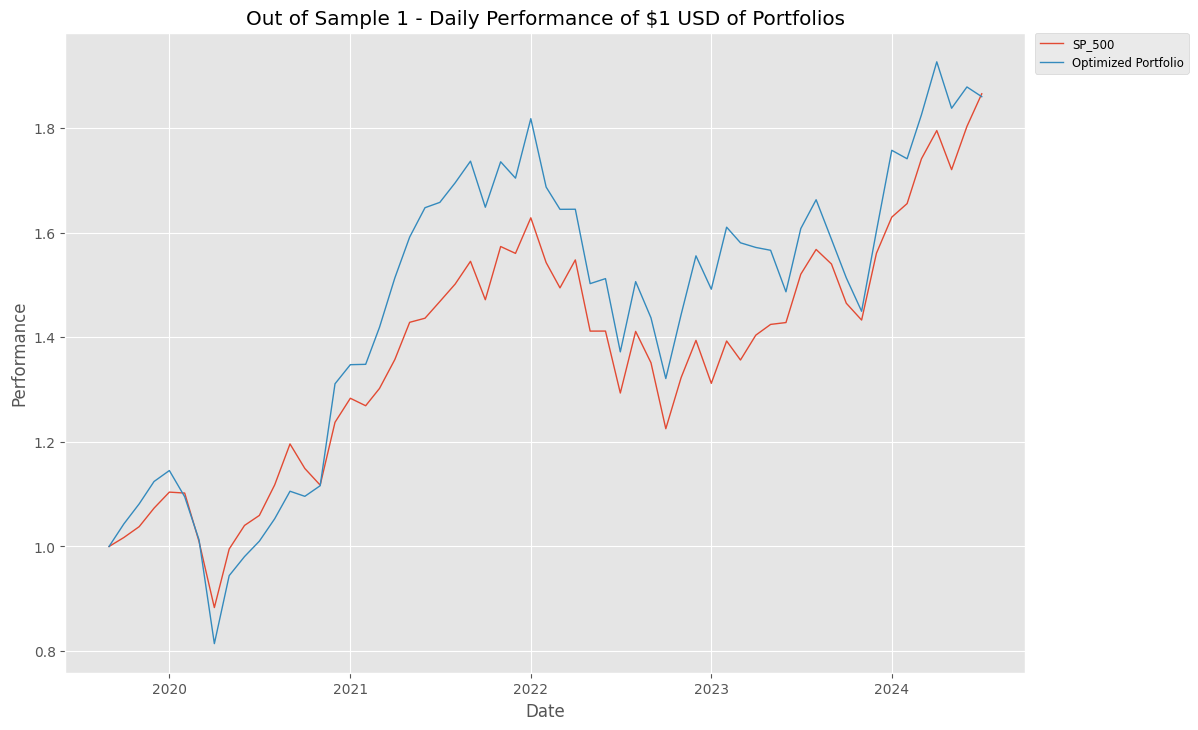

In [413]:
visual()

In [24]:
def random_generate_beta(l,u):
    upper_limit=u
    lower_limit=l
    random_number=round(random.uniform(lower_limit, upper_limit), 2)
    return random_number

In [40]:
testing_beta_mkt=random_generate_beta(1,1.2)
testing_beta_val=random_generate_beta(0,0)
testing_beta_smb=random_generate_beta(0,0)
print(testing_beta_mkt, testing_beta_val,testing_beta_smb)
def run_with_backtestss(nyears):
    
    global n_years
    n_years=nyears
    current_date()
    simulator(testing_beta_mkt,testing_beta_val,testing_beta_smb,n_year_before,n_year_after,1000000,50) 
    out_of_sample()
  
    return oos1_new_performance

run_with_backtestss(3)


1.02 0.0 0.0


[*********************100%%**********************]  501 of 501 completed

6 Failed downloads:
['GEV', 'SOLV', 'SW', 'VLTO']: Exception("%ticker%: Data doesn't exist for startDate = 1593576000, endDate = 1688184000")
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-07-01 -> 2023-07-01)')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  490 of 490 completed


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/645f92fe1ba44eabb5b5b0aad85fc6e5-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/645f92fe1ba44eabb5b5b0aad85fc6e5-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2529 COLUMNS
At line 44769 RHS
At line 47294 BOUNDS
At line 47785 ENDATA
Problem MODEL has 2524 rows, 2485 columns and 41224 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1054 rows, 1505 columns (490 integer (490 of which binary)) and 38284 elements
Cbc0038I Initial state - 36 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 2.17193 ite

[*********************100%%**********************]  36 of 36 completed
[*********************100%%**********************]  1 of 1 completed


Ticker,SP_500,Optimized Portfolio
Date,,
2023-08-01,1.000000,1.000000
2023-09-01,0.982284,0.982084
2023-10-01,0.934427,0.935691
2023-11-01,0.913889,0.906989
2023-12-01,0.995389,0.991257
2024-01-01,1.039414,1.042958
2024-02-01,1.055936,1.045114
2024-03-01,1.110550,1.046608
2024-04-01,1.144998,1.074531


In [109]:
sharess.to_excel('shares2.xlsx')

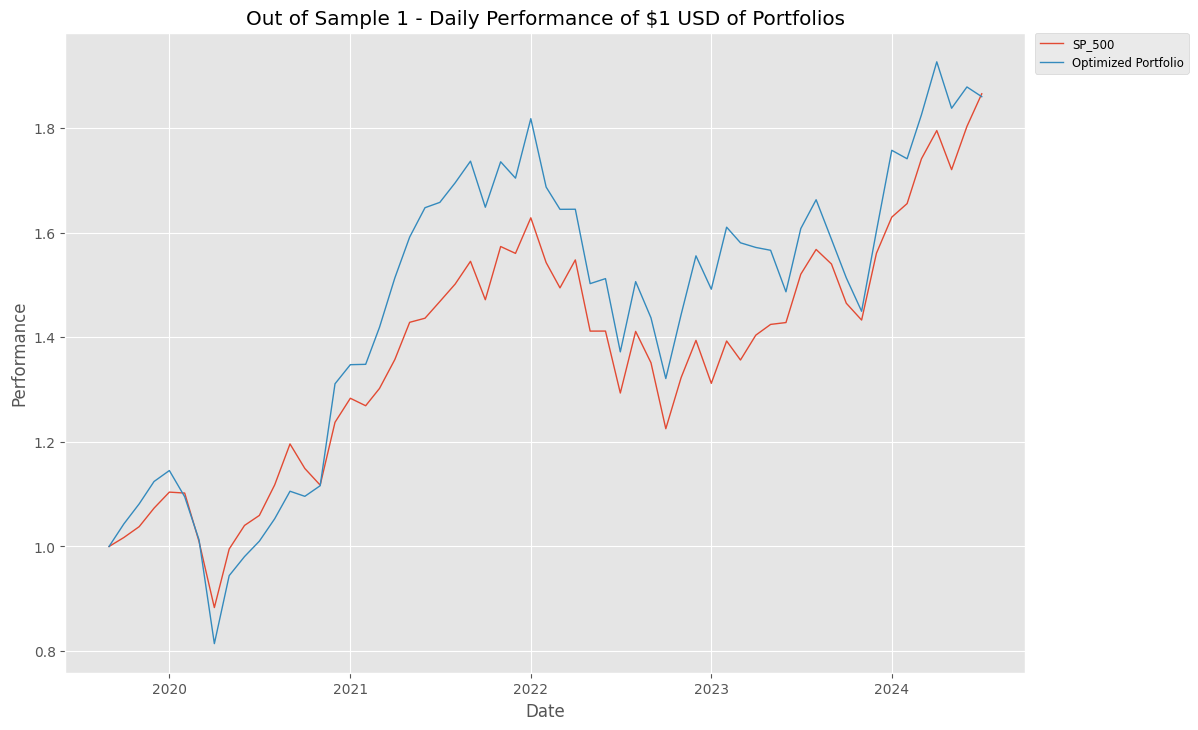

,Mkt-RF,SMB,HML,RF
Mkt-RF,1.000000,0.375112,0.087302,-0.132453
SMB,0.375112,1.000000,0.166171,-0.208541
HML,0.087302,0.166171,1.000000,-0.304060
RF,-0.132453,-0.208541,-0.304060,1.000000


In [414]:
visual()
ff3_monthly.corr()

In [41]:
simulator(1,0,0,'2020-03-01','2023-01-01',1000000,50) 
port_betas
out_of_sample()

[*********************100%%**********************]  501 of 501 completed

7 Failed downloads:
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-03-01 -> 2023-01-01)')
['GEV', 'SOLV', 'KVUE', 'VLTO']: Exception("%ticker%: Data doesn't exist for startDate = 1583038800, endDate = 1672549200")
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
['GEHC']: IndexError('index 0 is out of bounds for axis 0 with size 0')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  490 of 490 completed


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/47a56c3f37a94d3c946f06441f10e449-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/47a56c3f37a94d3c946f06441f10e449-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2525 COLUMNS
At line 42797 RHS
At line 45318 BOUNDS
At line 45809 ENDATA
Problem MODEL has 2520 rows, 2483 columns and 39258 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.06 seconds
Cgl0004I processed model has 1050 rows, 1503 columns (490 integer (490 of which binary)) and 36318 elements
Cbc0038I Initial state - 34 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 1.73589 ite

[*********************100%%**********************]  34 of 34 completed
[*********************100%%**********************]  1 of 1 completed


Ticker,SP_500,Optimized Portfolio
Date,,
2023-03-01,1.000000,1.000000
2023-04-01,1.035052,1.037034
2023-05-01,1.050207,1.032959
2023-06-01,1.052814,1.018456
2023-07-01,1.120960,1.087384
2023-08-01,1.155866,1.109311
2023-09-01,1.135388,1.078588
2023-10-01,1.080073,1.017738
2023-11-01,1.056333,0.970299


In [48]:
simulator(1,0,0,'2020-02-01','2023-01-01',1000000,50) 
port_betas
out_of_sample()

[*********************100%%**********************]  501 of 501 completed

6 Failed downloads:
['VLTO', 'KVUE', 'SOLV', 'GEV']: Exception("%ticker%: Data doesn't exist for startDate = 1580533200, endDate = 1672549200")
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2020-02-01 -> 2023-01-01)')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  490 of 490 completed


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/c22237c3835e4600ac8c8c3bf2cd055d-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/c22237c3835e4600ac8c8c3bf2cd055d-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2527 COLUMNS
At line 43784 RHS
At line 46307 BOUNDS
At line 46798 ENDATA
Problem MODEL has 2522 rows, 2484 columns and 40242 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0 - 0.05 seconds
Cgl0004I processed model has 1052 rows, 1504 columns (490 integer (490 of which binary)) and 37302 elements
Cbc0038I Initial state - 34 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 2.1138 iter

[*********************100%%**********************]  35 of 35 completed
[*********************100%%**********************]  1 of 1 completed


Ticker,SP_500,Optimized Portfolio
Date,,
2023-03-01,1.000000,1.000000
2023-04-01,1.035052,1.039673
2023-05-01,1.050207,1.040838
2023-06-01,1.052814,1.051704
2023-07-01,1.120960,1.120231
2023-08-01,1.155866,1.170409
2023-09-01,1.135388,1.143553
2023-10-01,1.080073,1.084424
2023-11-01,1.056333,1.049101


In [46]:
simulator(1.71,0.30,0.8,'2018-05-01','2021-06-01',1000000,50) 
port_betas

[*********************100%%**********************]  501 of 501 completed

8 Failed downloads:
['KVUE', 'GEHC', 'GEV', 'SOLV', 'CEG', 'VLTO']: Exception("%ticker%: Data doesn't exist for startDate = 1525147200, endDate = 1622520000")
['BF.B']: Exception('%ticker%: No price data found, symbol may be delisted (1mo 2018-05-01 -> 2021-06-01)')
['BRK.B']: Exception('%ticker%: No timezone found, symbol may be delisted')
[*********************100%%**********************]  1 of 1 completed
[*********************100%%**********************]  484 of 484 completed


Welcome to the CBC MILP Solver 
Version: 2.10.3 
Build Date: Dec 15 2019 

command line - /Library/Frameworks/Python.framework/Versions/3.12/lib/python3.12/site-packages/pulp/solverdir/cbc/osx/64/cbc /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/9c471d7413e64b19a83412b6b1c54fba-pulp.mps -timeMode elapsed -branch -printingOptions all -solution /var/folders/l4/hkz5jfdx3t581gbl8x7mfqs40000gn/T/9c471d7413e64b19a83412b6b1c54fba-pulp.sol (default strategy 1)
At line 2 NAME          MODEL
At line 3 ROWS
At line 2501 COLUMNS
At line 45200 RHS
At line 47697 BOUNDS
At line 48182 ENDATA
Problem MODEL has 2496 rows, 2456 columns and 41694 elements
Coin0008I MODEL read with 0 errors
Option for timeMode changed from cpu to elapsed
Continuous objective value is 0.221365 - 0.08 seconds
Cgl0004I processed model has 1044 rows, 1488 columns (484 integer (484 of which binary)) and 38790 elements
Cbc0038I Initial state - 27 integers unsatisfied sum - 1
Cbc0038I Pass   1: suminf.    0.00000 (0) obj. 3.22

,SP_500,Target,Optimization,Abs. Diff
Mkt-RF,0.969685,1.71,1.625159,0.0848
SMB,-0.172165,0.30,0.316681,0.0167
HML,0.036521,0.80,0.725837,0.0742


In [20]:
sharess.to_excel('shares1.xlsx')

In [25]:
#future price function

def get_last_future_price(symbol):
    future = yf.Ticker(symbol)
    data = future.history(period="1d")
    last_price = data['Close'].iloc[-1]
    return last_price


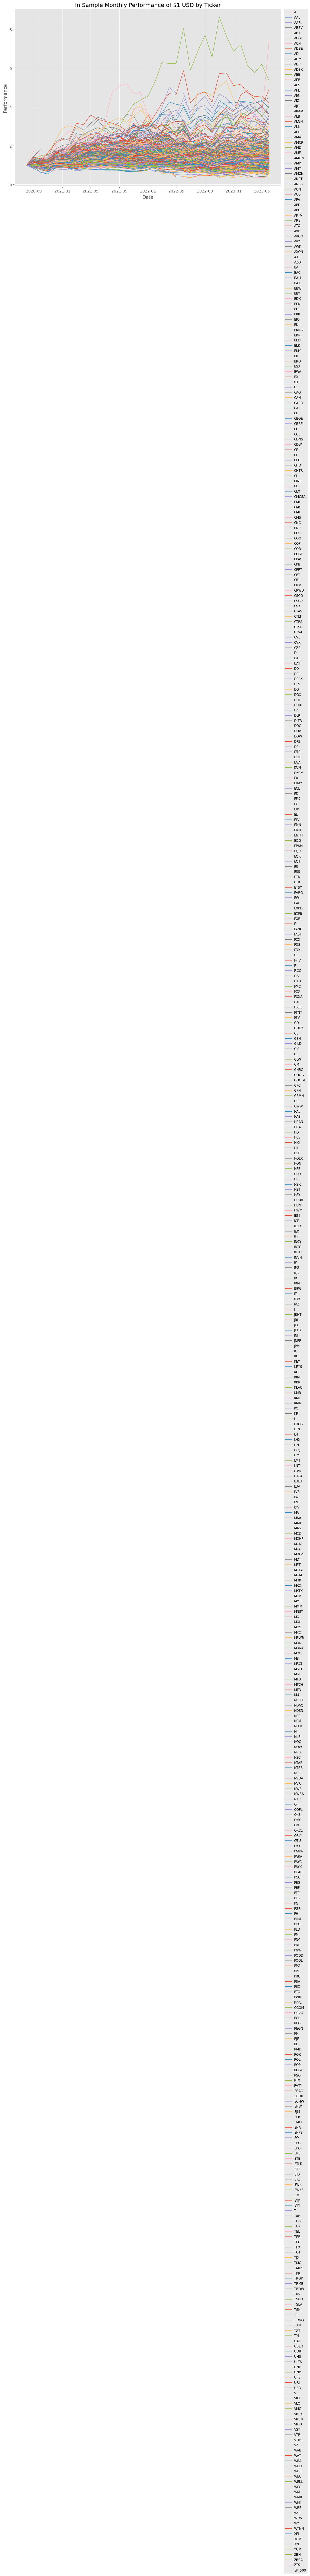

In [82]:
#Adjusting tickers list as some tickers will not be included in the monthly_data if there is no data for test date range
tickers = list(monthly_data.columns[:-1])
tick_index = tickers + ['SP_500']
init = 1        #Initial Common Value (Can be thought of Initial Investment of $1 USD in each stock)
global performance
performance = pd.DataFrame(np.ones((len(monthly_data),len(monthly_data.columns))), index = monthly_data.index, columns = monthly_data.columns)
for j in range(1,len(monthly_data.index)):
    performance.iloc[j] = performance.iloc[j-1]*(monthly_data.iloc[j-1][monthly_data.columns]+init)
plt.style.use('ggplot')
fig = plt.figure(figsize=(12,8), dpi=100)
axes = fig.add_axes([0.1, 0.1, 0.8, 0.8])   # left, bottom, width, height (range 0 to 1)

# Plot on that set of axes
for i in range(0,len(monthly_data.columns)):
        axes.plot(performance.index, performance.iloc[:,i], linewidth=1)

#axes.set_prop_cycle(cycler)
axes.set_xlabel('Date')
axes.set_ylabel('Performance')
axes.set_title('In Sample Monthly Performance of $1 USD by Ticker')
axes.legend(tick_index, bbox_to_anchor=(1.01, 1), loc='upper left', borderaxespad=0, fontsize='small')

plt.show()